## 1. Importations et configurations

In [1]:
import os
import re
import optuna
import jinja2
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier, XGBRegressor
from IPython.display import display, clear_output
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

# Configuration pour un meilleur affichage des graphiques
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Définition des fonctions utilitaires

In [2]:
def save_plot(folder="image", default_name="figure"):
    """
    Enregistre automatiquement le plot actuel dans le dossier spécifié,
    en utilisant le titre de la figure comme nom de fichier.
    """
    # 1. Créer le dossier s'il n'existe pas
    os.makedirs(folder, exist_ok=True)
    
    # 2. Récupérer le titre de l'axe courant
    title = plt.gca().get_title()
    
    if not title:
        title = default_name
        
    # 3. Nettoyer le titre pour en faire un nom de fichier valide
    clean_title = title.lower()
            
    # Remplacer tout ce qui n'est pas alphanumérique par un underscore
    filename = re.sub(r'[^a-z0-9_-]', '_', clean_title)
    filename = re.sub(r'_+', '_', filename).strip('_') # Éviter les underscores multiples
    
    if not filename:
        filename = default_name
        
    # 4. Construire le chemin complet et sauvegarder
    filepath = os.path.join(folder, f"{filename}.png")
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"✔ Graphique sauvegardé : {filepath}")

In [3]:
def explorer_dataset_interactif(df):
    """
    Version optimisée pour grands datasets : analyse rapide avec échantillonnage 
    pour les contrôles textuels lourds.
    """
    summary_data = []
    n_rows = len(df)
    
    # Échantillon de travail pour les vérifications textuelles lourdes (accélère grandement le traitement)
    df_sample = df.head(5000) if n_rows > 5000 else df
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_nan = df[col].isna().sum()
        pct_nan = round((n_nan / n_rows) * 100, 2)
        n_unique = df[col].nunique()
        
        # Range / Min-Max pour les numériques
        col_range = "-"
        if pd.api.types.is_numeric_dtype(df[col]):
            if n_rows - n_nan > 0:
                col_range = f"Min: {df[col].min()} | Max: {df[col].max()}"
        
        comments = []
        non_nulls_sample = df_sample[col].dropna()
        
        # 1. Chiffres en format texte
        if dtype in ['object', 'string'] and len(non_nulls_sample) > 0:
            try:
                converted = pd.to_numeric(non_nulls_sample, errors='coerce')
                if converted.notna().sum() / len(non_nulls_sample) > 0.8:
                    comments.append("⚠️ Chiffres en texte (ex: '1'). À convertir.")
            except:
                pass
        
        # 2. Chaînes vides ou espaces seuls (sur l'échantillon)
        if dtype in ['object', 'string'] and len(non_nulls_sample) > 0:
            empty_str = (df_sample[col] == '').sum()
            space_str = (df_sample[col].astype(str).str.strip() == '').sum() - empty_str
            if empty_str > 0:
                comments.append("⚠️ Chaînes vides ''")
            if space_str > 0:
                comments.append("⚠️ Espaces seuls ' '")
        
        # 3. Valeurs infinies
        if pd.api.types.is_numeric_dtype(df[col]):
            if np.isinf(df[col]).sum() > 0:
                comments.append("❌ Valeurs infinies (inf)")
        
        # 4. Colonnes constantes
        if n_unique == 1:
            comments.append("ℹ️ Colonne constante (1 seule valeur)")
            
        # 5. Espaces superflus (sur l'échantillon)
        if dtype in ['object', 'string'] and len(non_nulls_sample) > 0:
            try:
                if non_nulls_sample.astype(str).str.contains(r'^\s+|\s+$', regex=True).any():
                    comments.append("⚠️ Espaces début/fin (.str.strip())")
            except:
                pass
                
        comment_str = " | ".join(comments) if comments else "RAS"
        
        summary_data.append({
            'Colonne': col,
            'Type': dtype,
            'Unique': n_unique,
            'NaN Count': n_nan,
            '% NaN': pct_nan,
            'Range / Min-Max': col_range,
            'Commentaires & Anomalies': comment_str
        })
        
    summary_df = pd.DataFrame(summary_data)
    
    # --- INTERACTIVITÉ ---
    type_options = ['Tous'] + list(summary_df['Type'].unique())
    type_dropdown = widgets.Dropdown(options=type_options, value='Tous', description='Type:')
    nan_checkbox = widgets.Checkbox(value=False, description='Uniquement avec NaN')
    anomaly_checkbox = widgets.Checkbox(value=False, description='Uniquement avec Anomalies')
    
    out = widgets.Output()
    
    def update_table(*args):
        filtered_df = summary_df.copy()
        if type_dropdown.value != 'Tous':
            filtered_df = filtered_df[filtered_df['Type'] == type_dropdown.value]
        if nan_checkbox.value:
            filtered_df = filtered_df[filtered_df['NaN Count'] > 0]
        if anomaly_checkbox.value:
            filtered_df = filtered_df[filtered_df['Commentaires & Anomalies'].str.contains('⚠️|❌|ℹ️')]
        
        with out:
            clear_output(wait=True)
            display(
                filtered_df.style
                .set_table_styles([
                    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '8px')]},
                    {'selector': 'td', 'props': [('padding', '6px')]}
                ])
            )
            
    type_dropdown.observe(update_table, names='value')
    nan_checkbox.observe(update_table, names='value')
    anomaly_checkbox.observe(update_table, names='value')
    
    display(widgets.VBox([
        widgets.HTML("<h3>🛠️ Tableau de Bord d'Exploration (Optimisé)</h3>"),
        widgets.HBox([type_dropdown, nan_checkbox, anomaly_checkbox]),
        out
    ]))
    
    update_table()

In [4]:
def get_outliers_iqr(df, column_name=None):
    """
    Identifie les lignes considérées comme des valeurs aberrantes 
    en utilisant la méthode de l'écart interquartile (IQR).
    Ignore les NaN automatiquement.
    """
    # Si aucune colonne n'est spécifiée, on parcourt toutes les colonnes exploitables
    if column_name is None:
        outliers_dict = {}
        for col in df.columns:
            col_series = pd.to_numeric(df[col], errors='coerce')
            if not col_series.dropna().empty:
                res = get_outliers_iqr(df, column_name=col)
                if not res.empty:
                    outliers_dict[col] = res
        return outliers_dict

    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return pd.DataFrame()
    
    # Conversion sécurisée : les textes et espaces deviennent des NaN (ignorés ensuite)
    col_series = pd.to_numeric(df[column_name], errors='coerce')
    
    if col_series.dropna().empty:
        return pd.DataFrame()

    # Calcul des quartiles (les NaN sont ignorés par défaut par .quantile())
    Q1 = col_series.quantile(0.25)
    Q3 = col_series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Les NaN renvoient False et sont exclus des outliers
    outliers = df[(col_series < lower_bound) | (col_series > upper_bound)]
    print(f"✔ {len(outliers)} outlier(s) détectés dans '{column_name}'")
    
    return outliers

In [5]:
def missing_values_table(df):
    """
    Renvoie un DataFrame résumant le nombre et le pourcentage 
    de valeurs manquantes pour chaque colonne 
    (incluant les NaN, None, chaînes vides '' et espaces ' ').
    """
    # Création d'une copie pour ne pas altérer le DataFrame d'origine
    df_temp = df.copy()
    
    # Remplacement des chaînes vides ou composées uniquement d'espaces par np.nan
    for col in df_temp.columns:
        if df_temp[col].dtype == 'object' or pd.api.types.is_string_dtype(df_temp[col]):
            df_temp[col] = df_temp[col].replace(r'^\s*$', np.nan, regex=True)
    
    mis_val = df_temp.isnull().sum()
    mis_val_percent = 100 * df_temp.isnull().sum() / len(df_temp)
    
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: 'Valeurs Manquantes', 1: '% du Total'}
    )
    
    # Filtrer uniquement les colonnes avec des valeurs manquantes et trier
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns['Valeurs Manquantes'] > 0
    ].sort_values(by='% du Total', ascending=False)
    
    print(f"Le DataFrame comporte {df.shape[1]} colonnes au total.")
    print(f"Il y a {len(mis_val_table_ren_columns)} colonnes avec des valeurs manquantes.")
    
    return mis_val_table_ren_columns

In [6]:
def inspect_column(df, column_name, max_unique=15):
    """
    Affiche les valeurs uniques et leur fréquence si le nombre 
    de valeurs uniques est inférieur ou égal à max_unique.
    """
    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return

    n_unique = df[column_name].nunique()
    
    if n_unique <= max_unique:
        print(f"✔ Colonne '{column_name}' : {n_unique} valeurs uniques trouvées.")
        display(df[column_name].value_counts(dropna=False))
        print("-" * 40)
    else:
        print(f"✖ Colonne '{column_name}' : {n_unique} valeurs uniques (dépasse le seuil de {max_unique}).")
        print("-" * 40)

In [7]:
def evaluate_classification_model(y_true, y_pred, y_prob=None):
    """
    Affiche un dictionnaire ou un DataFrame propre des métriques de classification.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Rappel)": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
        
    df_metrics = pd.DataFrame(metrics, index=["Score"]).T
    return df_metrics

In [8]:
def plot_custom_confusion_matrix(y_true, y_pred, labels=["Non Churn", "Churn"]):
    """
    Affiche une matrice de confusion stylisée avec des pourcentages et des valeurs absolues.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.title("Matrice de Confusion")
    plt.xlabel("Prédiction du Modèle")
    plt.ylabel("Valeurs Réelles")
    plt.tight_layout()

## 3. Chargement des données

In [9]:
# Chargement du dataset depuis le chemin local
df = pd.read_csv("archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.info()

# Affichage des 5 premières lignes
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploration des données

In [10]:
explorer_dataset_interactif(df)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
print("--- DÉTECTION DES OUTLIERS SUR TOUT LE DATAFRAME ---")
outliers_dict = get_outliers_iqr(df)

--- DÉTECTION DES OUTLIERS SUR TOUT LE DATAFRAME ---
✔ 1142 outlier(s) détectés dans 'SeniorCitizen'
✔ 0 outlier(s) détectés dans 'tenure'
✔ 0 outlier(s) détectés dans 'MonthlyCharges'
✔ 0 outlier(s) détectés dans 'TotalCharges'


In [13]:
# Application de la fonction sur le DataFrame actuel
missing_df = missing_values_table(df)

if not missing_df.empty:
    display(missing_df)
else:
    print("Aucune valeur manquante détectée (hors éventuels espaces vides non convertis).")

Le DataFrame comporte 21 colonnes au total.
Il y a 1 colonnes avec des valeurs manquantes.


,Valeurs Manquantes,% du Total
TotalCharges,11,0.156183


## 5. Nettoyage et Préprocessing des données

In [14]:
class TelcoPreprocesseur(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Copie pour éviter de modifier le DataFrame d'origine
        X_ = X.copy()
        
        # 1 & 2. Conversion de TotalCharges
        if 'TotalCharges' in X_.columns:
            X_['TotalCharges'] = pd.to_numeric(X_['TotalCharges'], errors='coerce')
            
        # 3. Conversion des colonnes binaires
        binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
        for col in binary_cols:
            if col in X_.columns:
                X_[col] = X_[col].map({'Yes': 1, 'No': 0})
                
        if 'gender' in X_.columns:
            X_['gender'] = X_['gender'].map({'Male': 1, 'Female': 0})
            
        # 4. Conversion des colonnes ternaires
        ternary_cols = [
            'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]
        for col in ternary_cols:
            if col in X_.columns:
                X_[col] = X_[col].replace({
                    'No phone service': 'No',
                    'No internet service': 'No'
                })
                X_[col] = X_[col].map({'Yes': 1, 'No': 0})
                
        # --- 5. FEATURE ENGINEERING (Création des colonnes requises) ---
        # TotalServices : Somme de tous les services souscrits par le client
        service_cols = [
            'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]
        existing_services = [col for col in service_cols if col in X_.columns]
        if existing_services:
            X_['TotalServices'] = X_[existing_services].sum(axis=1)
            
        # ChargesPerTenure : Ratio charges totales / ancienneté (sécurité division par zéro)
        if 'TotalCharges' in X_.columns and 'tenure' in X_.columns:
            X_['ChargesPerTenure'] = X_['TotalCharges'] / (X_['tenure'] + 1)
            
        # IsNewCustomer : Indique si le client a une ancienneté inférieure ou égale à 1 mois
        if 'tenure' in X_.columns:
            X_['IsNewCustomer'] = (X_['tenure'] <= 1).astype(int)
        # -------------------------------------------------------------
                
        # 6. One-Hot Encoding pour éliminer les chaînes de caractères (comme 'DSL')
        categorical_cols = ['Contract', 'PaymentMethod', 'InternetService']
        cat_present = [col for col in categorical_cols if col in X_.columns]
        if cat_present:
            X_ = pd.get_dummies(X_, columns=cat_present, drop_first=True)
            
        # Suppression de l'identifiant si présent
        if 'customerID' in X_.columns:
            X_ = X_.drop(columns=['customerID'])
            
        return X_

In [15]:
# --- 1. Définition du préprocesseur de données ---
numeric_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 
    'TotalServices', 'ChargesPerTenure', 'IsNewCustomer'
]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_cols)
    ],
    remainder='passthrough'
)

# --- 2. Dictionnaire des modèles à comparer ---
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=4, 
        scale_pos_weight=3, # Gestion du déséquilibre de classe
        random_state=42, 
        eval_metric='logloss'
    )
}

In [16]:
# Séparation initiale brute (avant tout traitement pour éviter le data leakage)
if 'Churn' in df.columns:
    X = df.drop(columns=['Churn'])
    y = df['Churn'].map({'Yes': 1, 'No': 0}) # Sécurisation de la cible si besoin
else:
    X = df.copy()

# Split Train/Test sur les données brutes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Modélisation et Evaluation

--- Tableau comparatif des performances ---
                 Logistic Regression  Random Forest  XGBoost
Accuracy                      0.8155         0.7828   0.7466
Precision                     0.6926         0.6206   0.5145
Recall (Rappel)               0.5481         0.4679   0.8075
F1-Score                      0.6119         0.5335   0.6285
ROC-AUC                       0.8482         0.8266   0.8435
Score ROC AUC (Logistic Regression) : 0.8482
Score ROC AUC (Random Forest) : 0.8266
Score ROC AUC (XGBoost) : 0.8435


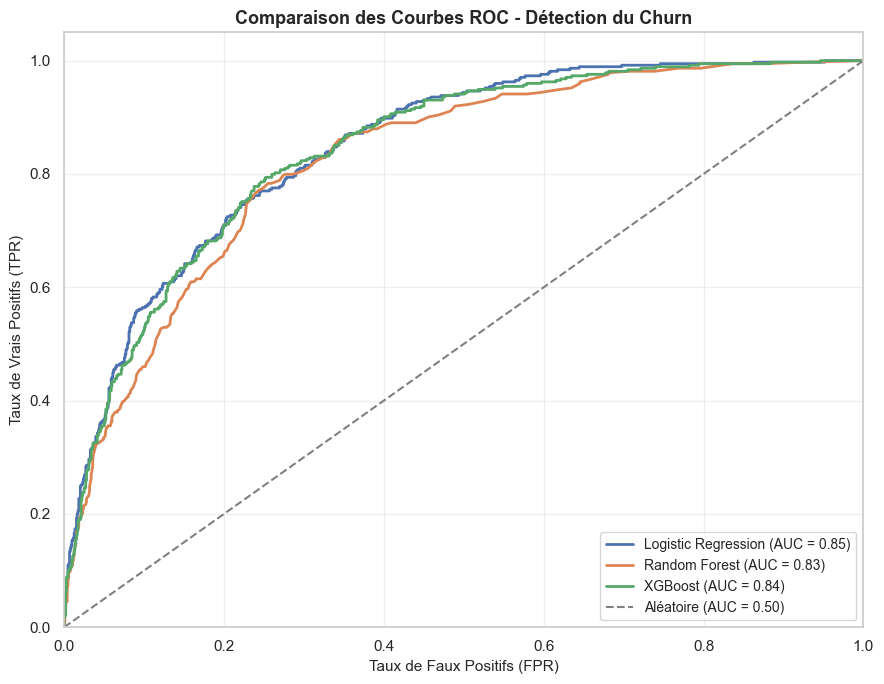

In [17]:
evaluation_results = {}
y_probs = {}  # Dictionnaire pour stocker les probabilités de chaque modèle

for name, model in models.items():
    # Pipeline global : Feature Engineering -> Standardisation -> Modèle
    full_pipeline = Pipeline(steps=[
        ('feature_engineering', TelcoPreprocesseur()),
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Entraînement sur le jeu d'entraînement
    full_pipeline.fit(X_train, y_train)
    
    # Prédictions sur le jeu de test
    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test)[:, 1]
    
    # Stockage des probabilités pour le graphique ROC
    y_probs[name] = y_proba
    
    # Appel de votre fonction d'évaluation
    df_eval = evaluate_classification_model(y_test, y_pred, y_proba)
    evaluation_results[name] = df_eval['Score']

# --- 4. Affichage du tableau comparatif global ---
df_comparison = pd.DataFrame(evaluation_results)
print("--- Tableau comparatif des performances ---")
print(df_comparison.round(4))

# --- 5. Tracé combiné des courbes ROC pour tous les modèles ---
plt.figure(figsize=(9, 7))

for name, y_proba_val in y_probs.items():
    # Calcul du score ROC AUC et des courbes
    auc_score = roc_auc_score(y_test, y_proba_val)
    print(f"Score ROC AUC ({name}) : {auc_score:.4f}")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_val)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.2f})')

# Ligne diagonale de référence (classifieur aléatoire)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Aléatoire (AUC = 0.50)')

# Configuration des axes et du graphique
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
plt.title('Comparaison des Courbes ROC - Détection du Churn', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Affichage final
plt.tight_layout()
plt.show()

In [18]:
# 1. Création d'un pipeline uniquement pour le prétraitement
data_pipeline = Pipeline(steps=[
    ('feature_engineering', TelcoPreprocesseur()),
    ('preprocessor', preprocessor)
])

# On transforme les données une seule fois pour accélérer Optuna
X_train_prep = data_pipeline.fit_transform(X_train)
X_test_prep = data_pipeline.transform(X_test)

# 2. Définition de la fonction objectif d'Optuna
def objective(trial):
    param = {
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'random_state': 42,
        'early_stopping_rounds': 50,
        'eval_metric': 'auc'
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_prep, y_train)):
        X_fit, X_val = X_train_prep[train_idx], X_train_prep[val_idx]
        y_fit, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**param)
        model.fit(
            X_fit, y_fit,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, preds)
        auc_scores.append(auc)

        # --- Reporting intermédiaire pour le pruner ---
        # On reporte la moyenne cumulée jusqu'ici (pas juste ce fold isolé)
        intermediate_value = np.mean(auc_scores)
        trial.report(intermediate_value, step=fold_idx)

        # Si le trial est clairement moins bon que la médiane des autres trials
        # à ce stade, on arrête pour ne pas gaspiller de temps de calcul
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(auc_scores)

In [19]:
# 3. Création de l'étude Optuna (on cherche à maximiser le ROC-AUC)
study = optuna.create_study(
    direction='maximize',
    study_name="Optimisation_XGBoost_Churn",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,   # les 5 premiers trials tournent toujours en entier (pour établir une médiane fiable)
        n_warmup_steps=2      # à l'intérieur d'un trial, on attend au moins 2 folds avant de pouvoir le couper
    )
)

print("Début de l'optimisation Optuna...")
study.optimize(objective, n_trials=50)

print("\n--- Meilleurs hyperparamètres trouvés ---")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print(f"Meilleur score de validation (ROC-AUC): {study.best_value:.4f}")

[I 2026-07-31 17:17:52,888] A new study created in memory with name: Optimisation_XGBoost_Churn


Début de l'optimisation Optuna...


[I 2026-07-31 17:17:55,377] Trial 0 finished with value: 0.8481735768936642 and parameters: {'learning_rate': 0.01567978637996889, 'max_depth': 7, 'min_child_weight': 9, 'subsample': 0.7010180557309922, 'colsample_bytree': 0.9008450964013088, 'gamma': 4.984353252325827, 'scale_pos_weight': 2.2181071573952544}. Best is trial 0 with value: 0.8481735768936642.
[I 2026-07-31 17:17:57,613] Trial 1 finished with value: 0.8493959301295243 and parameters: {'learning_rate': 0.03439768564813781, 'max_depth': 3, 'min_child_weight': 4, 'subsample': 0.9192387823455723, 'colsample_bytree': 0.5436867554875762, 'gamma': 3.3771644556638405, 'scale_pos_weight': 3.1126932409580017}. Best is trial 1 with value: 0.8493959301295243.
[I 2026-07-31 17:17:58,684] Trial 2 finished with value: 0.8438367539204601 and parameters: {'learning_rate': 0.17855834185263397, 'max_depth': 9, 'min_child_weight': 5, 'subsample': 0.5500335581925779, 'colsample_bytree': 0.7976927494097734, 'gamma': 3.0968066340193183, 'scale_


--- Meilleurs hyperparamètres trouvés ---
learning_rate: 0.04770629566457864
max_depth: 3
min_child_weight: 5
subsample: 0.5104676761539573
colsample_bytree: 0.8879789568173495
gamma: 0.5350682806831579
scale_pos_weight: 2.127195447021467
Meilleur score de validation (ROC-AUC): 0.8513


In [20]:
# 4. Entraînement du modèle final avec les meilleurs paramètres
best_xgb_params = study.best_params
best_xgb_params['n_estimators'] = 1500
best_xgb_params['random_state'] = 42
best_xgb_params['early_stopping_rounds'] = 50   # <-- ajouté ici, au constructeur
best_xgb_params['eval_metric'] = 'auc'          # <-- ajouté ici aussi

optimized_xgb = XGBClassifier(**best_xgb_params)

final_pipeline = Pipeline(steps=[
    ('feature_engineering', TelcoPreprocesseur()),
    ('preprocessor', preprocessor),
    ('classifier', optimized_xgb)
])

# On ne passe plus que eval_set et verbose à .fit()
final_pipeline.fit(
    X_train, y_train,
    classifier__eval_set=[(X_test_prep, y_test)],
    classifier__verbose=False
)

# 5. Évaluation finale du modèle optimisé
y_pred_opt = final_pipeline.predict(X_test)
y_proba_opt = final_pipeline.predict_proba(X_test)[:, 1]

# On ajoute le résultat au dictionnaire de la question précédente !
df_eval_opt = evaluate_classification_model(y_test, y_pred_opt, y_proba_opt)
evaluation_results['XGBoost Optimisé (Optuna)'] = df_eval_opt['Score']
y_probs['XGBoost Optimisé (Optuna)'] = y_proba_opt

# Affichage du nouveau tableau de comparaison
df_comparison_final = pd.DataFrame(evaluation_results)
print("\n--- Nouveau tableau comparatif des performances ---")
print(df_comparison_final.round(4))


--- Nouveau tableau comparatif des performances ---
                 Logistic Regression  Random Forest  XGBoost  \
Accuracy                      0.8155         0.7828   0.7466   
Precision                     0.6926         0.6206   0.5145   
Recall (Rappel)               0.5481         0.4679   0.8075   
F1-Score                      0.6119         0.5335   0.6285   
ROC-AUC                       0.8482         0.8266   0.8435   

                 XGBoost Optimisé (Optuna)  
Accuracy                            0.7615  
Precision                           0.5361  
Recall (Rappel)                     0.7540  
F1-Score                            0.6267  
ROC-AUC                             0.8476  


In [21]:
from sklearn.metrics import precision_recall_curve

def objective_f1(trial):
    param = {
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'random_state': 42,
        'early_stopping_rounds': 50,
        'eval_metric': 'auc'  # early stopping reste sur AUC (plus stable pour arrêter l'entraînement)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_prep, y_train)):
        X_fit, X_val = X_train_prep[train_idx], X_train_prep[val_idx]
        y_fit, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**param)
        model.fit(
            X_fit, y_fit,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds_proba = model.predict_proba(X_val)[:, 1]

        # --- Recherche du seuil optimal pour le F1 sur ce fold ---
        precisions, recalls, thresholds = precision_recall_curve(y_val, preds_proba)
        # F1 pour chaque seuil (on évite la division par zéro)
        f1_per_threshold = np.divide(
            2 * precisions * recalls,
            precisions + recalls,
            out=np.zeros_like(precisions),
            where=(precisions + recalls) != 0
        )
        best_f1 = np.max(f1_per_threshold)
        f1_scores.append(best_f1)

        # --- Reporting pour le pruner ---
        intermediate_value = np.mean(f1_scores)
        trial.report(intermediate_value, step=fold_idx)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(f1_scores)

In [22]:
study_f1 = optuna.create_study(
    direction='maximize',
    study_name="Optimisation_XGBoost_Churn_F1",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)

print("Début de l'optimisation Optuna (objectif F1)...")
study_f1.optimize(objective_f1, n_trials=50)

print("\n--- Meilleurs hyperparamètres trouvés (optimisés pour F1) ---")
for key, value in study_f1.best_params.items():
    print(f"{key}: {value}")
print(f"Meilleur score de validation (F1): {study_f1.best_value:.4f}")

[I 2026-07-31 17:21:06,983] A new study created in memory with name: Optimisation_XGBoost_Churn_F1


Début de l'optimisation Optuna (objectif F1)...


[I 2026-07-31 17:21:08,438] Trial 0 finished with value: 0.645254884040461 and parameters: {'learning_rate': 0.10396660552197055, 'max_depth': 7, 'min_child_weight': 10, 'subsample': 0.905761860533755, 'colsample_bytree': 0.5665134362895907, 'gamma': 1.1244613064026425, 'scale_pos_weight': 1.7752054489050746}. Best is trial 0 with value: 0.645254884040461.
[I 2026-07-31 17:21:10,958] Trial 1 finished with value: 0.6498176250959379 and parameters: {'learning_rate': 0.03303184132645614, 'max_depth': 9, 'min_child_weight': 8, 'subsample': 0.5169101705384016, 'colsample_bytree': 0.5001448919328741, 'gamma': 4.860313159351509, 'scale_pos_weight': 1.053725876902757}. Best is trial 1 with value: 0.6498176250959379.
[I 2026-07-31 17:21:13,840] Trial 2 finished with value: 0.6375124209076961 and parameters: {'learning_rate': 0.033061393161362515, 'max_depth': 7, 'min_child_weight': 4, 'subsample': 0.976876358670787, 'colsample_bytree': 0.9728626621178413, 'gamma': 1.4097386375241516, 'scale_pos


--- Meilleurs hyperparamètres trouvés (optimisés pour F1) ---
learning_rate: 0.025004246564085363
max_depth: 4
min_child_weight: 9
subsample: 0.7002169439304994
colsample_bytree: 0.5430465592139396
gamma: 0.6363892764280874
scale_pos_weight: 1.7319012787448784
Meilleur score de validation (F1): 0.6511


In [23]:
# Split validation interne pour calibrer le seuil (indépendant de X_test)
X_fit_idx, X_calib_idx, y_fit_final, y_calib = train_test_split(
    np.arange(len(y_train)), y_train, test_size=0.2, random_state=42, stratify=y_train
)
X_fit_final = X_train_prep[X_fit_idx]
X_calib = X_train_prep[X_calib_idx]

best_f1_params = study_f1.best_params
best_f1_params['n_estimators'] = 1500
best_f1_params['random_state'] = 42
best_f1_params['early_stopping_rounds'] = 50
best_f1_params['eval_metric'] = 'auc'

xgb_f1_model = XGBClassifier(**best_f1_params)
xgb_f1_model.fit(
    X_fit_final, y_fit_final,
    eval_set=[(X_calib, y_calib)],
    verbose=False
)

# Recherche du seuil optimal sur le jeu de calibration
calib_proba = xgb_f1_model.predict_proba(X_calib)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_calib, calib_proba)
f1_per_threshold = np.divide(
    2 * precisions * recalls, precisions + recalls,
    out=np.zeros_like(precisions), where=(precisions + recalls) != 0
)
best_threshold_idx = np.argmax(f1_per_threshold)
best_threshold = thresholds[best_threshold_idx] if best_threshold_idx < len(thresholds) else 0.5
print(f"Seuil optimal trouvé : {best_threshold:.4f}")

# Évaluation finale sur X_test, avec le seuil calibré (pas 0.5 par défaut !)
y_proba_f1_test = xgb_f1_model.predict_proba(X_test_prep)[:, 1]
y_pred_f1_test = (y_proba_f1_test >= best_threshold).astype(int)

df_eval_f1 = evaluate_classification_model(y_test, y_pred_f1_test, y_proba_f1_test)
evaluation_results['XGBoost Optimisé F1 (Optuna)'] = df_eval_f1['Score']
y_probs['XGBoost Optimisé F1 (Optuna)'] = y_proba_f1_test

df_comparison_final = pd.DataFrame(evaluation_results)
print("\n--- Tableau comparatif mis à jour ---")
print(df_comparison_final.round(4))

Seuil optimal trouvé : 0.5061

--- Tableau comparatif mis à jour ---
                 Logistic Regression  Random Forest  XGBoost  \
Accuracy                      0.8155         0.7828   0.7466   
Precision                     0.6926         0.6206   0.5145   
Recall (Rappel)               0.5481         0.4679   0.8075   
F1-Score                      0.6119         0.5335   0.6285   
ROC-AUC                       0.8482         0.8266   0.8435   

                 XGBoost Optimisé (Optuna)  XGBoost Optimisé F1 (Optuna)  
Accuracy                            0.7615                        0.7835  
Precision                           0.5361                        0.5782  
Recall (Rappel)                     0.7540                        0.6818  
F1-Score                            0.6267                        0.6258  
ROC-AUC                             0.8476                        0.8473  


In [24]:
def objective_f1_v2(trial):
    param = {
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'random_state': 42,
        'early_stopping_rounds': 50,
        'eval_metric': 'auc'
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Tableau pour stocker les prédictions Out-of-Fold, alignées sur y_train
    oof_proba = np.zeros(len(y_train))

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_prep, y_train)):
        X_fit, X_val = X_train_prep[train_idx], X_train_prep[val_idx]
        y_fit, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**param)
        model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

        # On stocke les prédictions à leur position d'origine (positionnelle)
        oof_proba[val_idx] = model.predict_proba(X_val)[:, 1]

        # Reporting intermédiaire pour le pruner (AUC, plus stable que F1 fold par fold)
        partial_auc = roc_auc_score(y_train.iloc[val_idx], oof_proba[val_idx])
        trial.report(partial_auc, step=fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # --- Un seul seuil, cherché sur l'ensemble des prédictions OOF agrégées ---
    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
    f1_per_threshold = np.divide(
        2 * precisions * recalls, precisions + recalls,
        out=np.zeros_like(precisions), where=(precisions + recalls) != 0
    )
    best_idx = np.argmax(f1_per_threshold)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    # On stocke le seuil trouvé pour pouvoir le réutiliser après (sans le recalculer différemment)
    trial.set_user_attr('threshold', float(best_threshold))

    return f1_per_threshold[best_idx]

In [25]:
study_f1_v2 = optuna.create_study(
    direction='maximize',
    study_name="Optimisation_XGBoost_Churn_F1_OOF",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)

study_f1_v2.optimize(objective_f1_v2, n_trials=50)

best_threshold_final = study_f1_v2.best_trial.user_attrs['threshold']
print(f"Meilleur F1 (OOF, seuil unique) : {study_f1_v2.best_value:.4f}")
print(f"Seuil associé : {best_threshold_final:.4f}")

[I 2026-07-31 17:23:20,771] A new study created in memory with name: Optimisation_XGBoost_Churn_F1_OOF
[I 2026-07-31 17:23:23,719] Trial 0 finished with value: 0.634009009009009 and parameters: {'learning_rate': 0.0343009558802079, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.7836122569393581, 'colsample_bytree': 0.8709935775641787, 'gamma': 3.507971205326761, 'scale_pos_weight': 4.402311866164232}. Best is trial 0 with value: 0.634009009009009.
[I 2026-07-31 17:23:30,101] Trial 1 finished with value: 0.6377236726312702 and parameters: {'learning_rate': 0.014878856953607694, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.795418410528425, 'colsample_bytree': 0.6713191051750129, 'gamma': 2.954492434892127, 'scale_pos_weight': 4.526463713613579}. Best is trial 1 with value: 0.6377236726312702.
[I 2026-07-31 17:23:34,249] Trial 2 finished with value: 0.6377245508982036 and parameters: {'learning_rate': 0.15230876077448555, 'max_depth': 9, 'min_child_weight': 10, 'subsample'

Meilleur F1 (OOF, seuil unique) : 0.6431
Seuil associé : 0.3074


In [26]:
best_f1_params_v2 = study_f1_v2.best_params
best_f1_params_v2['n_estimators'] = 1500
best_f1_params_v2['random_state'] = 42
best_f1_params_v2['early_stopping_rounds'] = 50
best_f1_params_v2['eval_metric'] = 'auc'

# On entraîne sur tout X_train, avec un petit sous-ensemble pour l'early stopping
X_fit_idx, X_es_idx = train_test_split(
    np.arange(len(y_train)), test_size=0.15, random_state=42, stratify=y_train
)

xgb_f1_v2 = XGBClassifier(**best_f1_params_v2)
xgb_f1_v2.fit(
    X_train_prep[X_fit_idx], y_train.iloc[X_fit_idx],
    eval_set=[(X_train_prep[X_es_idx], y_train.iloc[X_es_idx])],
    verbose=False
)

y_proba_f1_v2 = xgb_f1_v2.predict_proba(X_test_prep)[:, 1]
y_pred_f1_v2 = (y_proba_f1_v2 >= best_threshold_final).astype(int)

df_eval_f1_v2 = evaluate_classification_model(y_test, y_pred_f1_v2, y_proba_f1_v2)
evaluation_results['XGBoost Optimisé F1 v2 (OOF)'] = df_eval_f1_v2['Score']

print(pd.DataFrame(evaluation_results).round(4))

                 Logistic Regression  Random Forest  XGBoost  \
Accuracy                      0.8155         0.7828   0.7466   
Precision                     0.6926         0.6206   0.5145   
Recall (Rappel)               0.5481         0.4679   0.8075   
F1-Score                      0.6119         0.5335   0.6285   
ROC-AUC                       0.8482         0.8266   0.8435   

                 XGBoost Optimisé (Optuna)  XGBoost Optimisé F1 (Optuna)  \
Accuracy                            0.7615                        0.7835   
Precision                           0.5361                        0.5782   
Recall (Rappel)                     0.7540                        0.6818   
F1-Score                            0.6267                        0.6258   
ROC-AUC                             0.8476                        0.8473   

                 XGBoost Optimisé F1 v2 (OOF)  
Accuracy                               0.7559  
Precision                              0.5271  
Recall (Rappel

In [27]:
def objective_lr(trial):
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    C = trial.suggest_float('C', 1e-4, 10.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    params = {
        'C': C,
        'penalty': penalty,
        'solver': 'saga',   # seul solver compatible avec l1 ET elasticnet
        'max_iter': 5000,
        'random_state': 42,
        'class_weight': class_weight
    }
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    model = LogisticRegression(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # cross_val_predict régénère un modèle par fold et assemble les prédictions OOF
    oof_proba = cross_val_predict(
        model, X_train_prep, y_train, cv=skf, method='predict_proba', n_jobs=-1
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
    f1_per_threshold = np.divide(
        2 * precisions * recalls, precisions + recalls,
        out=np.zeros_like(precisions), where=(precisions + recalls) != 0
    )
    best_idx = np.argmax(f1_per_threshold)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    trial.set_user_attr('threshold', float(best_threshold))

    return f1_per_threshold[best_idx]

study_lr = optuna.create_study(direction='maximize', study_name="Optimisation_LR_F1_OOF", pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2))
study_lr.optimize(objective_lr, n_trials=100)  # LR est rapide, on peut se permettre plus de trials

best_lr_threshold = study_lr.best_trial.user_attrs['threshold']
print(f"Meilleurs paramètres LR : {study_lr.best_params}")
print(f"Meilleur F1 (OOF) : {study_lr.best_value:.4f} | Seuil : {best_lr_threshold:.4f}")

[I 2026-07-31 17:25:28,793] A new study created in memory with name: Optimisation_LR_F1_OOF
[I 2026-07-31 17:25:36,771] Trial 0 finished with value: 0.6381301041960011 and parameters: {'penalty': 'l2', 'C': 0.0062052136992849045, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6381301041960011.
[I 2026-07-31 17:25:44,722] Trial 1 finished with value: 0.6395173453996983 and parameters: {'penalty': 'l2', 'C': 6.747327601858434, 'class_weight': None}. Best is trial 1 with value: 0.6395173453996983.
[I 2026-07-31 17:25:44,940] Trial 2 finished with value: 0.6302357836338418 and parameters: {'penalty': 'elasticnet', 'C': 0.0012423275128688903, 'class_weight': 'balanced', 'l1_ratio': 0.025532867797662506}. Best is trial 1 with value: 0.6395173453996983.
[I 2026-07-31 17:25:45,074] Trial 3 finished with value: 0.4194136625052602 and parameters: {'penalty': 'elasticnet', 'C': 0.00021013240771151583, 'class_weight': None, 'l1_ratio': 0.21999150990894056}. Best is trial 1 with value: 

Meilleurs paramètres LR : {'penalty': 'elasticnet', 'C': 0.04109454895668873, 'class_weight': 'balanced', 'l1_ratio': 0.6361935599215378}
Meilleur F1 (OOF) : 0.6420 | Seuil : 0.5354


In [28]:
best_lr_params = dict(study_lr.best_params)
best_lr_params['solver'] = 'saga'
best_lr_params['max_iter'] = 5000
best_lr_params['random_state'] = 42

tuned_lr = LogisticRegression(**best_lr_params)
tuned_lr.fit(X_train_prep, y_train)

y_proba_lr_tuned = tuned_lr.predict_proba(X_test_prep)[:, 1]
y_pred_lr_tuned = (y_proba_lr_tuned >= best_lr_threshold).astype(int)

df_eval_lr_tuned = evaluate_classification_model(y_test, y_pred_lr_tuned, y_proba_lr_tuned)
evaluation_results['Logistic Regression Optimisée (Optuna)'] = df_eval_lr_tuned['Score']
y_probs['Logistic Regression Optimisée (Optuna)'] = y_proba_lr_tuned

print(pd.DataFrame(evaluation_results).round(4))

                 Logistic Regression  Random Forest  XGBoost  \
Accuracy                      0.8155         0.7828   0.7466   
Precision                     0.6926         0.6206   0.5145   
Recall (Rappel)               0.5481         0.4679   0.8075   
F1-Score                      0.6119         0.5335   0.6285   
ROC-AUC                       0.8482         0.8266   0.8435   

                 XGBoost Optimisé (Optuna)  XGBoost Optimisé F1 (Optuna)  \
Accuracy                            0.7615                        0.7835   
Precision                           0.5361                        0.5782   
Recall (Rappel)                     0.7540                        0.6818   
F1-Score                            0.6267                        0.6258   
ROC-AUC                             0.8476                        0.8473   

                 XGBoost Optimisé F1 v2 (OOF)  \
Accuracy                               0.7559   
Precision                              0.5271   
Recall (Rap

In [29]:
class TelcoPreprocesseurV2(TelcoPreprocesseur):
    def transform(self, X):
        X_ = X.copy()

        # --- Interactions calculées AVANT le one-hot encoding du parent ---
        # (on a besoin de 'Contract' sous sa forme brute, pas encore en dummies)
        if 'Contract' in X_.columns and 'tenure' in X_.columns:
            X_['Tenure_x_MonthToMonth'] = X_['tenure'] * (X_['Contract'] == 'Month-to-month').astype(int)

        if 'Contract' in X_.columns and 'MonthlyCharges' in X_.columns:
            X_['Charges_x_MonthToMonth'] = X_['MonthlyCharges'] * (X_['Contract'] == 'Month-to-month').astype(int)

        # --- Bucket d'ancienneté (la relation tenure/churn n'est pas forcément linéaire) ---
        if 'tenure' in X_.columns:
            X_['TenureBucket'] = pd.cut(
                X_['tenure'],
                bins=[-1, 6, 12, 24, 48, np.inf],
                labels=['0-6m', '6-12m', '12-24m', '24-48m', '48m+']
            ).astype(str)

        # On délègue le reste (conversions, TotalServices, ChargesPerTenure,
        # IsNewCustomer, one-hot de Contract/PaymentMethod/InternetService,
        # suppression de customerID) à la classe parente
        X_ = super().transform(X_)

        # Le parent ne connaît pas TenureBucket -> on l'encode ici
        if 'TenureBucket' in X_.columns:
            X_ = pd.get_dummies(X_, columns=['TenureBucket'], drop_first=True)

        return X_


# --- Préprocesseur v2 : on ajoute les 2 nouvelles colonnes numériques à standardiser ---
numeric_cols_v2 = numeric_cols + ['Tenure_x_MonthToMonth', 'Charges_x_MonthToMonth']

num_transformer_v2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_v2 = ColumnTransformer(
    transformers=[('num', num_transformer_v2, numeric_cols_v2)],
    remainder='passthrough'
)

data_pipeline_v2 = Pipeline(steps=[
    ('feature_engineering', TelcoPreprocesseurV2()),
    ('preprocessor', preprocessor_v2)
])

X_train_prep_v2 = data_pipeline_v2.fit_transform(X_train)
X_test_prep_v2 = data_pipeline_v2.transform(X_test)

print(f"Nombre de features avant FE : {X_train_prep.shape[1]}")
print(f"Nombre de features après FE : {X_train_prep_v2.shape[1]}")

Nombre de features avant FE : 26
Nombre de features après FE : 32


In [30]:
# --- Logistic Regression tunée + FE ---
tuned_lr_fe = LogisticRegression(**best_lr_params)
oof_lr_fe = cross_val_predict(
    tuned_lr_fe, X_train_prep_v2, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    method='predict_proba', n_jobs=-1
)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_lr_fe)
f1s = np.divide(2*prec*rec, prec+rec, out=np.zeros_like(prec), where=(prec+rec) != 0)
threshold_lr_fe = thr[np.argmax(f1s)] if np.argmax(f1s) < len(thr) else 0.5

tuned_lr_fe.fit(X_train_prep_v2, y_train)
y_proba_lr_fe = tuned_lr_fe.predict_proba(X_test_prep_v2)[:, 1]
y_pred_lr_fe = (y_proba_lr_fe >= threshold_lr_fe).astype(int)

evaluation_results['Logistic Regression + FE'] = evaluate_classification_model(y_test, y_pred_lr_fe, y_proba_lr_fe)['Score']
y_probs['Logistic Regression + FE'] = y_proba_lr_fe

# --- XGBoost optimisé F1 (v2) + FE ---
best_xgb_fe_params = dict(best_f1_params_v2)
tuned_xgb_fe = XGBClassifier(**best_xgb_fe_params)

X_fit_idx, X_es_idx = train_test_split(
    np.arange(len(y_train)), test_size=0.15, random_state=42, stratify=y_train
)
tuned_xgb_fe.fit(
    X_train_prep_v2[X_fit_idx], y_train.iloc[X_fit_idx],
    eval_set=[(X_train_prep_v2[X_es_idx], y_train.iloc[X_es_idx])],
    verbose=False
)

y_proba_xgb_fe = tuned_xgb_fe.predict_proba(X_test_prep_v2)[:, 1]
y_pred_xgb_fe = (y_proba_xgb_fe >= best_threshold_final).astype(int)  # seuil déjà trouvé précédemment

evaluation_results['XGBoost F1 + FE'] = evaluate_classification_model(y_test, y_pred_xgb_fe, y_proba_xgb_fe)['Score']
y_probs['XGBoost F1 + FE'] = y_proba_xgb_fe

print(pd.DataFrame(evaluation_results).round(4))

                 Logistic Regression  Random Forest  XGBoost  \
Accuracy                      0.8155         0.7828   0.7466   
Precision                     0.6926         0.6206   0.5145   
Recall (Rappel)               0.5481         0.4679   0.8075   
F1-Score                      0.6119         0.5335   0.6285   
ROC-AUC                       0.8482         0.8266   0.8435   

                 XGBoost Optimisé (Optuna)  XGBoost Optimisé F1 (Optuna)  \
Accuracy                            0.7615                        0.7835   
Precision                           0.5361                        0.5782   
Recall (Rappel)                     0.7540                        0.6818   
F1-Score                            0.6267                        0.6258   
ROC-AUC                             0.8476                        0.8473   

                 XGBoost Optimisé F1 v2 (OOF)  \
Accuracy                               0.7559   
Precision                              0.5271   
Recall (Rap

In [31]:
stacking_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(**best_lr_params)),
        ('xgb', XGBClassifier(**{k: v for k, v in best_xgb_fe_params.items() if k != 'early_stopping_rounds'}))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Seuil optimal via OOF (attention : plus lent, le stacking refait sa propre CV interne à chaque fold externe)
oof_stack = cross_val_predict(
    stacking_model, X_train_prep_v2, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    method='predict_proba', n_jobs=-1
)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_stack)
f1s = np.divide(2*prec*rec, prec+rec, out=np.zeros_like(prec), where=(prec+rec) != 0)
threshold_stack = thr[np.argmax(f1s)] if np.argmax(f1s) < len(thr) else 0.5

stacking_model.fit(X_train_prep_v2, y_train)
y_proba_stack = stacking_model.predict_proba(X_test_prep_v2)[:, 1]
y_pred_stack = (y_proba_stack >= threshold_stack).astype(int)

evaluation_results['Stacking (LR + XGBoost)'] = evaluate_classification_model(y_test, y_pred_stack, y_proba_stack)['Score']
y_probs['Stacking (LR + XGBoost)'] = y_proba_stack

print(pd.DataFrame(evaluation_results).round(4))

                 Logistic Regression  Random Forest  XGBoost  \
Accuracy                      0.8155         0.7828   0.7466   
Precision                     0.6926         0.6206   0.5145   
Recall (Rappel)               0.5481         0.4679   0.8075   
F1-Score                      0.6119         0.5335   0.6285   
ROC-AUC                       0.8482         0.8266   0.8435   

                 XGBoost Optimisé (Optuna)  XGBoost Optimisé F1 (Optuna)  \
Accuracy                            0.7615                        0.7835   
Precision                           0.5361                        0.5782   
Recall (Rappel)                     0.7540                        0.6818   
F1-Score                            0.6267                        0.6258   
ROC-AUC                             0.8476                        0.8473   

                 XGBoost Optimisé F1 v2 (OOF)  \
Accuracy                               0.7559   
Precision                              0.5271   
Recall (Rap

In [32]:
skf_err = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_oof_proba = np.zeros(len(y_train))

for train_idx, val_idx in skf_err.split(X_train_prep_v2, y_train):
    X_fit, X_val = X_train_prep_v2[train_idx], X_train_prep_v2[val_idx]
    y_fit, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    m = XGBClassifier(**best_xgb_fe_params)
    m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
    base_oof_proba[val_idx] = m.predict_proba(X_val)[:, 1]

residuals_train = y_train.values - base_oof_proba

error_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
oof_correction = cross_val_predict(
    error_model, X_train_prep_v2, residuals_train,
    cv=KFold(5, shuffle=True, random_state=42), n_jobs=-1
)

corrected_oof_proba = np.clip(base_oof_proba + oof_correction, 0, 1)

prec_base, rec_base, _ = precision_recall_curve(y_train, base_oof_proba)
f1_base = np.max(np.divide(2*prec_base*rec_base, prec_base+rec_base,
                            out=np.zeros_like(prec_base), where=(prec_base+rec_base) != 0))

prec_corr, rec_corr, thr_corr = precision_recall_curve(y_train, corrected_oof_proba)
f1_corr_arr = np.divide(2*prec_corr*rec_corr, prec_corr+rec_corr,
                         out=np.zeros_like(prec_corr), where=(prec_corr+rec_corr) != 0)
best_idx_corr = np.argmax(f1_corr_arr)
f1_corr = f1_corr_arr[best_idx_corr]

print(f"F1 (OOF) AVANT correction : {f1_base:.4f}")
print(f"F1 (OOF) APRÈS correction : {f1_corr:.4f}")

F1 (OOF) AVANT correction : 0.6429
F1 (OOF) APRÈS correction : 0.6289
